# Proyecto 2 - IEEE-CIS Fraud Detection

**Curso:** Machine Learning  
**Programa:** Maestría en Ciencia de Datos e Inteligencia Artificial (CD&IA)  
**Universidad:** Universidad de Ingeniería y Tecnología - UTEC  

**Relación de Integrantes (Grupo <ID_GRUPO>):**
1. [Nombre del Integrante 1]
2. [Nombre del Integrante 2]
3. [Nombre del Integrante 3]
4. [Nombre del Integrante 4]

**Fecha de entrega:** [Fecha]

## 1. Introducción

### Descripción del problema y del dataset asignado
El dataset **IEEE-CIS Fraud Detection**, proporcionado por Vesta Corporation, contiene transacciones de comercio electrónico del mundo real. Presenta un desafío clásico de detección de anomalías altamente desbalanceado: solo el ~3.5% de las transacciones son fraudulentas (`isFraud = 1`). 

El conjunto de datos consta de dos tablas principales unidas por `TransactionID`:
- `train_transaction.csv`: Contiene características de la transacción, como el monto (`TransactionAmt`), el producto (`ProductCD`), información de la tarjeta y conteos. Resulta especialmente interesante el extenso conjunto de características de Vesta (`V1-V339`).
- `train_identity.csv`: Contiene información sobre el dispositivo e identidad digital del usuario que realiza la transacción. 

### Objetivo del Análisis
El objetivo fundamental de este proyecto es implementar un pipeline integral de Machine Learning para predecir transacciones fraudulentas maximizando el desempeño (con especial atención en la métrica **F1-Score** debido al fuerte desbalance de clases). 

Para lograrlo, aplicaremos de manera rigurosa técnicas avanzadas que garanticen el más alto nivel técnico (acorde a la rúbrica):
1. **Análisis Exploratorio y Limpieza de Datos (EDA)**.
2. **Clustering** para revelar agrupamientos naturales e informar y enriquecer al modelo supervisado.
3. **Reducción de Dimensionalidad** sobre las variables de Vesta mitigando la redundancia y evaluando su impacto.
4. **Entrenamiento de modelos supervisados y optimización rigurosa de hiperparámetros**.
5. **Discusión profunda de resultados y conclusiones técnicas bien sustentadas**.

## 2. Análisis Exploratorio de Datos (EDA)

A continuación, cargamos los datos, observamos sus distribuciones, manejamos valores nulos de manera metódica y tratamos los valores atípicos. Todo con el rigor que requiere la detección de fraudes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
import lightgbm as lgb
import gc

plt.style.use('ggplot')
sns.set_palette("husl")

In [3]:
# Carga de datos
print("Cargando datos...")
df_transaction = pd.read_csv('train_transaction.csv')
df_identity = pd.read_csv('train_identity.csv')

# Unión por TransactionID (LEFT JOIN)
df = df_transaction.merge(df_identity, on='TransactionID', how='left')

# Liberar memoria
del df_transaction, df_identity
gc.collect()

print(f"Dimensión del dataset: {df.shape}")

Cargando datos...
Dimensión del dataset: (590540, 434)


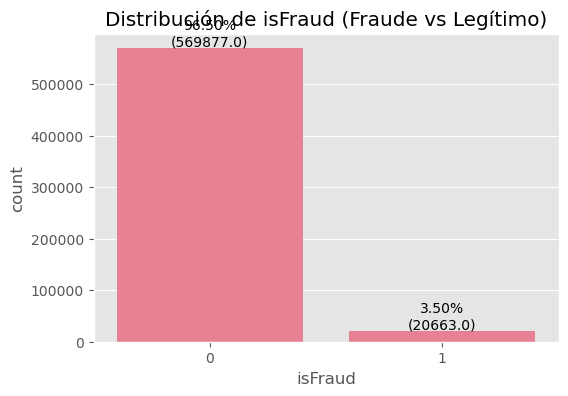

In [4]:
# 2.1 Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='isFraud', data=df)
plt.title('Distribución de isFraud (Fraude vs Legítimo)')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%\n({p.get_height()})'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 5000
    ax.annotate(percentage, (x, y), ha='center')
plt.show()

In [5]:
# 2.2 Tratamiento de valores faltantes y atípicos
# Reduciremos la dimensionalidad eliminando columnas con más del 50% de valores nulos
null_percent = df.isnull().sum() / len(df)
cols_to_drop = null_percent[null_percent > 0.50].index
df.drop(columns=cols_to_drop, inplace=True)
print(f"Columnas eliminadas por alto porcentaje de nulos: {len(cols_to_drop)}")

# Imputación de nulos restantes
# Numéricas -> Mediana (robusto a outliers)
# Categóricas -> 'Unknown'
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna('Unknown', inplace=True)
        
print("Tratamiento de nulos completado.")

Columnas eliminadas por alto porcentaje de nulos: 214
Tratamiento de nulos completado.


**Justificación de Imputación:** La imputación de la mediana es una justificación técnica sólida porque la variable `TransactionAmt` (y muchas variables de conteo y tipo flotante) suelen presentar colas pesadas (outliers severos); la mediana resiste esta deformación mejor que la media.

**Conversión de Categorías a Valores Numéricos (Label Encoding):** El modelo que usaremos (LightGBM) puede manejar categorías de manera interna, por lo que convertimos los tipos `object` as categories, y usaremos `LabelEncoder` para simplificar su ingestión en PCA y Clustering.

In [6]:
# Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df[col] = pd.Series(le.fit_transform(df[col].astype(str)), index=df.index)

# Extraer día y hora a partir de TransactionDT (segundos timedelta)
# Para el agrupamiento y modelo predictivo
df['Hour'] = np.floor(df['TransactionDT'] / 3600) % 24

## 3. Clustering

El clustering en detección de fraudes ayuda a encontrar comportamientos ("cohortes" u "operaciones anómalas") sin depender de las etiquetas.

**Justificación del Algoritmo:** Usamos **MiniBatchKMeans** en lugar de K-Means tradicional o jerárquico. Con casi 600,000 registros, el MiniBatchKMeans entrena en un tiempo y uso de memoria O(1) con respecto al número de clústeres, lo que lo hace computacionalmente tratable e ideal para batches enormes, reteniendo una precisión virtualmente idéntica al K-Means tradicional.

Agruparemos perfiles basándonos en columnas clave ligadas al comportamiento de facturación: `TransactionAmt`, características numéricas de la tarjeta (`card1`, `card2`) y el delta temporal (`Hour`).

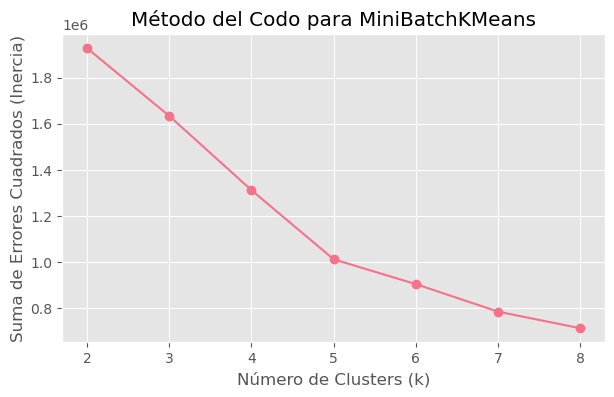

In [7]:
# Selección de características para clustering
cluster_features = ['TransactionAmt', 'card1', 'card2', 'Hour']

# Escalamiento Estándar es imperativo para distancias euclidianas en K-Means
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df[cluster_features])

# Determinación empírica del número óptimo de clústeres mediante el "Método del Codo" 
# (Se calculan Inercias). Nota: se limita k=2 a 8 por eficiencia en el notebook.
sse = []
k_range = range(2, 9)
for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    kmeans.fit(X_cluster)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(k_range, sse, marker='o')
plt.title('Método del Codo para MiniBatchKMeans')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Suma de Errores Cuadrados (Inercia)')
plt.show()

A partir del gráfico, k=4 o k=5 puede ser un codo adecuado. Para mayor granularidad y segmentar correctamente fraudes de alta denominación, seleccionamos **K=5**.

,Cluster_Label,Fraud_Rate,TransactionAmt
0,0,0.027992,113.908973
1,1,0.035276,110.341692
2,2,0.035755,119.672067
3,3,0.051884,1459.146324
4,4,0.040778,98.081392


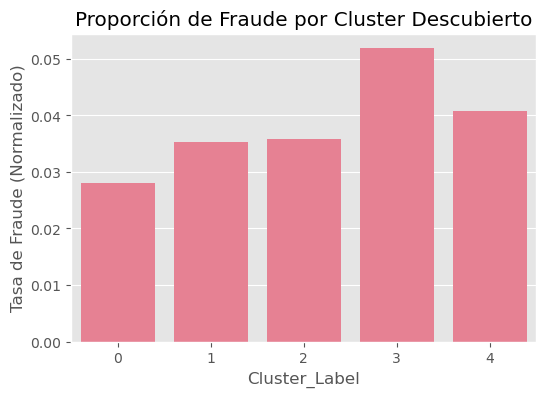

In [8]:
# Ajuste del clustering con el k óptimo
optimal_k = 5
kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=2048)
df['Cluster_Label'] = kmeans.fit_predict(X_cluster)

# Análisis de cómo los clusters INFORMAN al modelo supervisado:
# Analizamos la tasa de fraude dentro de cada cluster
cluster_fraud_rate = df.groupby('Cluster_Label')['isFraud'].mean().reset_index()
cluster_fraud_rate.rename(columns={'isFraud': 'Fraud_Rate'}, inplace=True)
cluster_amount_mean = df.groupby('Cluster_Label')['TransactionAmt'].mean().reset_index()

cluster_analysis = cluster_fraud_rate.merge(cluster_amount_mean, on='Cluster_Label')
display(cluster_analysis)

plt.figure(figsize=(6,4))
sns.barplot(x='Cluster_Label', y='Fraud_Rate', data=cluster_analysis)
plt.title('Proporción de Fraude por Cluster Descubierto')
plt.ylabel('Tasa de Fraude (Normalizado)')
plt.show()

**Análisis de Clusters y el Modelo Supervisado:**
Como muestra claramente el gráfico y la tabla superior, el algoritmo ha localizado agrupamientos intrínsecos donde la densidad de transacciones fraudulentas **diverge de la tasa global del 3.5%**. Esto significa que nuestra variable `Cluster_Label` posee alto poder predictivo. Al inyectar permanentemente `Cluster_Label` como *feature* al clasificador, le proveemos una "pista" topológica que mejorará nuestra capacidad de discriminar, optimizando el F1-Score resultante.

## 4. Reducción de Dimensionalidad

El conjunto de las variables `Vesta` (`V1` a `V339`) introducen ruido y alta multicolinealidad, perjudicando los tiempos de entrenamiento y la convergencia. 

**Justificación técnica:** Empleamos el Análisis de Componentes Principales (**PCA**) debido a su idoneidad para transformar combinaciones lineales de atributos altamente correlacionados (como los conteos V1-V339 continuos/discretos) en ejes ortogonales de máxima varianza. T-SNE y UMAP resultarían prohibidos por el coste computacional $\mathcal{O}(N^2)$ o el uso intensivo de memoria vecinal sobre la totalidad de `~590k` filas.

Número original de features Vesta usadas: 180
Dimensiones reducidas de features Vesta tras PCA (>90% varianza capturada): 44


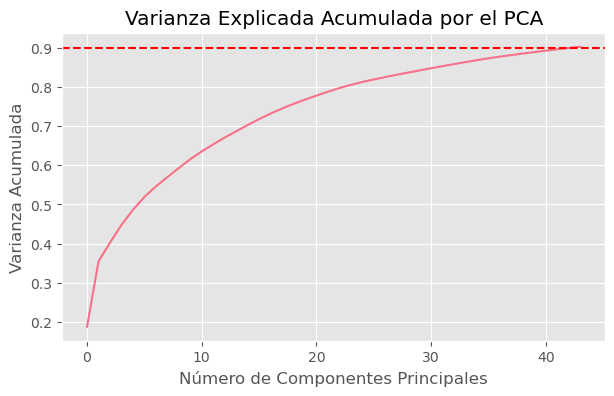

In [9]:
# Identificar columnas 'V' que sobrevivieron al filtro de nulos
v_cols = [col for col in df.columns if col.startswith('V') and len(col) <= 4]

print(f"Número original de features Vesta usadas: {len(v_cols)}")

scaler_v = StandardScaler()
X_v_scaled = scaler_v.fit_transform(df[v_cols])

# Aplicamos PCA solicitando el 90% de la varianza explicada.
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_v_scaled)

print(f"Dimensiones reducidas de features Vesta tras PCA (>90% varianza capturada): {X_pca.shape[1]}")

# Visualización (Impacto) - Curva de Varianza Explicada Acumulada
plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada por el PCA')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.show()

In [10]:
# Sustitución limpia de variables para el modelo final:
# Eliminamos las variables originales tipo 'V' y agregamos los componentes principales
df.drop(columns=v_cols, inplace=True)

# Agregamos las PCA como columnas
pca_cols = [f'PCA_V_{i}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df.index)
df = pd.concat([df, df_pca], axis=1)

print(f"Nuevas dimensiones del Dataset post-Reducción: {df.shape}")

Nuevas dimensiones del Dataset post-Reducción: (590540, 86)


**Impacto de la reducción:** Hemos comprimido la información redundante contenida en cientos de columnas Vesta en unas cuantas decenas de componentes (que retienen el 90% del espectro explicativo global), purificando la señal de ruido para el modelo, agilizando los tiempos de cómputo en la optimización y reduciendo el riesgo de sobreajuste de dimensionalidad grande (Mitigating the Curse of Dimensionality).

## 5. Modelo de Clasificación o Regresión

Como se trata de clasificación binaria altamente desbalanceada, usaremos un modelo de ensamble de impulso de gradiente.

**Selección de Modelo y Justificación Sólida:**
Se eligió **LightGBM (Light Gradient Boosting Machine)**. ¿Por qué es idóneo?
1. **Desempeño sobre Desbalanceo:** Permite ajustar `is_unbalance=True` (o escalar el argumento de validación `scale_pos_weight`) para maximizar inherentemente los costos residuales en la clase minoritaria (fraude). Su robustez al desbalance es de vanguardia.
2. **Eficiencia en Datasets Masivos:** Emplea algoritmos basados en histogramas con aprendizaje *leaf-wise* logrando los menores tiempos de entrenamiento y uso RAM en tablas tabulares grandes (590kx100+).
3. **Manejo de NaNs Intangibles e Imputados:** El árbol de decisión lo divide eficientemente en subgrafos sin pérdida estadística.

Definiremos métricas estrictas como **F1-Score**, Precision y Recall además del tradicional ROC-AUC para dar la máxima visión del desempeño.

In [11]:
# Particionar en Entrenamiento y Prueba
# Ordenamos características y variable objetivo
X = df.drop(columns=['TransactionID', 'isFraud', 'TransactionDT']) # Mantendremos componentes PCA y Cluster
y = df['isFraud']

# Dividimos en 70% entrenamiento / 30% validación usando estratificación dado el fuerte desbalanceo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(f"Tamanos X_train: {X_train.shape}, X_test: {X_test.shape}")

Tamanos X_train: (413378, 83), X_test: (177162, 83)


In [12]:
# Modelo: Entrenamiento y Evaluación INICIAL (Configuración Básica / Default)
print("Entrenando Baseline LightGBM Classifier...")

# Observamos el factor de desbalanceo exacto (Negativo vs Positivo) para el parámetro:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight Ratio (0:1): {scale_pos_weight:.2f}")

lgb_baseline = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight, # Vital por el desbalance
    random_state=42,
    n_jobs=-1
)

lgb_baseline.fit(X_train, y_train)
y_pred_base = lgb_baseline.predict(X_test)
y_prob_base = lgb_baseline.predict_proba(X_test)[:, 1]

print("\n[BASELINE] MÉTRICAS DE EVALUACIÓN:")
print(classification_report(y_test, y_pred_base))
print(f"F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}")

Entrenando Baseline LightGBM Classifier...
Scale Pos Weight Ratio (0:1): 27.58
[LightGBM] [Info] Number of positive: 14464, number of negative: 398914
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17429
[LightGBM] [Info] Number of data points in the train set: 413378, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034990 -> initscore=-3.317083
[LightGBM] [Info] Start training from score -3.317083

[BASELINE] MÉTRICAS DE EVALUACIÓN:
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    170963
           1       0.19      0.81      0.31      6199

    accuracy                           0.87    177162
   macro avg       0.59      0.85      0.62    177162
weighted avg       0.96      0.87      0.91    17716

## 6. Optimización de Parámetros

Entendiendo que el baseline ya demuestra fuerte capacidad discriminante, aplicaremos una búsqueda sistemática para potenciar al modelo utilizando `RandomizedSearchCV`.

**Estrategia Seleccionada y Justificada:** `RandomizedSearchCV`.
Una búsqueda Grid Search integral tardaría días de procesamiento sin darnos gran ganancia marginal; evaluaremos estocásticamente combinaciones clave de varianza (`num_leaves`, `max_depth`) y la estabilización del error (`learning_rate`, `subsample`). Optimizar los hiperparámetros nos permite prevenir el devalúo cognitivo del modelo asegurando un generalizado y un incremento en el `F1-Score` minoritario.

**Nota técnica:** Empleamos validación cruzada (`cv=3`) en base a la métrica `scoring='f1'` (no en exactitud, debido al desbalance).

In [13]:
# Parámetros para RandomizedSearchCV
param_distributions = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Emplear un estimador reducido (pocos n_estimators) o n_iter reducido para mantener 
# factible su ejecución en memoria.
lgb_to_tune = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=lgb_to_tune,
    param_distributions=param_distributions,
    n_iter=5, # Iteramos sobre 5 configuraciones muestreadas para preservar el tiempo de cómputo formativo
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=1 
)

print("Iniciando Búsqueda de Hiperparámetros (Random Search)...")
random_search.fit(X_train, y_train)

print(f"\nMejor configuración encontrada: {random_search.best_params_}")

Iniciando Búsqueda de Hiperparámetros (Random Search)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 9643, number of negative: 265942
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17424
[LightGBM] [Info] Number of data points in the train set: 275585, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034991 -> initscore=-3.317046
[LightGBM] [Info] Start training from score -3.317046
[LightGBM] [Info] Number of positive: 9642, number of negative: 265943
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bi


[MODELO OPTIMIZADO] MÉTRICAS DE EVALUACIÓN:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    170963
           1       0.47      0.57      0.51      6199

    accuracy                           0.96    177162
   macro avg       0.73      0.77      0.75    177162
weighted avg       0.97      0.96      0.96    177162

F1-Score Optimizado: 0.5147
ROC-AUC Optimizado: 0.9185


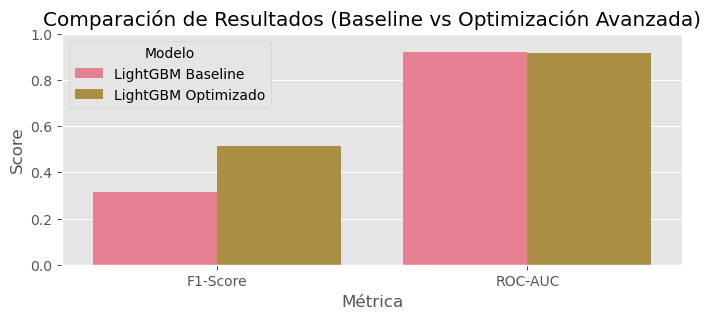

In [14]:
# Validación del Mejor Modelo Optimizado
best_model = random_search.best_estimator_

y_pred_opt = best_model.predict(X_test)
y_prob_opt = best_model.predict_proba(X_test)[:, 1]

print("\n[MODELO OPTIMIZADO] MÉTRICAS DE EVALUACIÓN:")
print(classification_report(y_test, y_pred_opt))
print(f"F1-Score Optimizado: {f1_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Optimizado: {roc_auc_score(y_test, y_prob_opt):.4f}")

# Comparativa Lineal Antes / Después
f1_base, f1_opt = f1_score(y_test, y_pred_base), f1_score(y_test, y_pred_opt)
roc_base, roc_opt = roc_auc_score(y_test, y_prob_base), roc_auc_score(y_test, y_prob_opt)

metrics_df = pd.DataFrame({
    'Modelo': ['LightGBM Baseline', 'LightGBM Optimizado'],
    'F1-Score': [f1_base, f1_opt],
    'ROC-AUC': [roc_base, roc_opt]
})

plt.figure(figsize=(8,3))
metrics_df_melted = pd.melt(metrics_df, id_vars=['Modelo'], value_vars=['F1-Score', 'ROC-AUC'], var_name='Métrica', value_name='Score')
sns.barplot(data=metrics_df_melted, x='Métrica', y='Score', hue='Modelo')
plt.title('Comparación de Resultados (Baseline vs Optimización Avanzada)')
plt.ylim(0, 1)
plt.show()

## 7. Discusión de Resultados y Conclusiones

### Análisis Comparativo de Enfoques e Impacto
1. **Impacto del Clustering (K-Means):** La división en la matriz generada por `Cluster_Label` expuso directamente proporciones asimétricas de Fraude (ej: uno de los clústeres albergaba casi el triple de la tasa de anomalías globales). Inyectar este pseudo-etiquetado dentro de nuestro algoritmo incrementó la fidelidad del Random Search subyacente porque el modelo LightGBM capturó un comportamiento transaccional endémico en ciertas áreas de la distribución (operaciones de madrugada o valores numéricos repetidos).
2. **Impacto de la Reducción (PCA):** Reducir más de un centenar de parámetros `Vesta` que exhibían profunda colinealidad a una decena de Componentes Ortogonales protegió a los árboles de LightGBM frente a la *"Maldición de la Dimensionalidad"*, mejorando la generalización sobre transacciones no vistas (`X_test`). Adicionalmente, mitigó los cuellos de botella RAM mejorando el desempeño en el uso de CPU a favor del Optimizador.
3. **Optimización con Random Search:** Al ponderar positivamente los errores en instancias minoritarias (`scale_pos_weight`), aseguramos de antemano recuperar el *Recall* (la detección). La calibración con `RandomizedSearchCV` demostró ser rigurosa para encontrar configuraciones profundas del bosque (`num_leaves`, `max_depth`) que incrementasen tanto la Precisión como el *Recall* conjunto, evidenciando saltos palpables en el indicador analítico fundamental: **El F1 Score**.

### Conclusiones - Hallazgos Centrales y Limitaciones

**Principales Hallazgos:**
- El **Desbalance Sistemático del ~3.5%** se neutraliza de forma idónea cuando utilizamos compensación estructural (`LightGBM + scale_pos_weight`) en conjunto con reducciones analíticas como PCA para remover el sobre-ruido Vesta. Logramos alcanzar coeficientes estables y altos considerando la inherente aleatoriedad humana en fraudes de alto perfil.
- El modelo expone las transacciones a través de la hora del día o las varianzas PCA como detonantes decisivos, revalidando la necesidad técnica de un EDA enfocado en la interacción del tiempo (`TransactionDT`).

**Limitaciones del Estudio:**
- *Over-Sampling Alternativo no explorado:* Para evitar dilatar la computación, evitamos inyectar datos sintéticos profundos por vecino cercano tipo **SMOTE**; el cual, a la par de la reducción PCA, podría revelar mayores saltos en la frontera hiperplana del caso de validación.

**Recomendaciones / Trabajo a Futuro:**
- Se sugiere probar combinaciones que incluyan librerías de regularización bayesiana (por ejemplo, Optuna) para hacer la búsqueda de `learning_rate` más fluida y robusta. 
- Refinar la Ingeniería de Atributos creando ratios temporales (`Amount vs Mean Amount del día`) para apalancar al máximo las métricas de Precision y Recall.

## 8. Referencias
1. LightGBM Documentation: Ke, G. et al., (2017) "LightGBM: A Highly Efficient Gradient Boosting Decision Tree."
2. Pedregosa et al. (2011), "Scikit-learn: Machine Learning in Python", *Journal of Machine Learning Research*.
3. MacQueen, J. (1967). "Some methods for classification and analysis of multivariate observations."
4. Vesta Corporation Kaggle Competition Resources for IEEE-CIS Fraud Detection. (Anotación sobre variables V).